# Comparing conditions and generating graphs for all conditions

In [15]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, ttest_1samp


In [16]:
#Defining project root
import sys
from pathlib import Path
# Make sure we can import config.py from project root

# One folder up from current notebook location
project_root = Path.cwd().parent.parent.resolve()

# Add subdirectories to path
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'config'))
print(f"Project root: {project_root}")
import config

Project root: /mnt/hdd/anatkorol/Imagination_in_translation


In [ ]:
# unite all dataframes into one
df = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/3_conditions_with_empty_delay.csv")
df_gpt = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/gpt_descs.csv")
df_wilma = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/other_datasets/wilmas_drawings_2019/wilmas_data_2019.csv")
# df_perc = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/10122025_pilot_2/nlp_analysis/ppt_w_gpt_semantic_tags.csv")
# df_im_mem = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/05012026_pilot_2_memory/nlp_analysis/ppt_w_gpt_semantic_tags.csv")
# df_delay_mem = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/09022026_pilot_2_delayed_memory/nlp_analysis/ppt_w_gpt_semantic_tags.csv")

In [18]:
# #add a condition column to each dataframe
# df_perc['condition'] = 'perception'
# df_im_mem['condition'] = 'immediate memory'
# df_delay_mem['condition'] = 'delayed memory'

In [6]:
# # remove the gpt from all, leave a single copy of descriptions
# df_perc = df_perc[df_perc["uid"].astype(str).str.strip() != "gpt-5"].copy()
# df_im_mem = df_im_mem[df_im_mem["uid"].astype(str).str.strip() != "gpt-5"].copy()


In [7]:
# df = pd.concat([df_perc, df_im_mem, df_delay_mem], ignore_index=True)

In [19]:
# turning the category details into actual lists instead of strings
import ast
list_cols = ['objects', 'attr_color', 'attr_shape', 'attr_size', 'attr_material', 'attr_texture', 'attr_pose', 'attr_action', 'attr_state', 'spatial_relations', 'world_knowledge','scene', 'camera_aspects', 'optical_effects', 'subjective_detail'] 

# turning the python strings into real lists
def to_list(x):
    # Already a list
    if isinstance(x, list):
        return x
    # Missing values
    if pd.isna(x):
        return []
    # String that looks like a list
    if isinstance(x, str):
        s = x.strip()
        if s == "" or s.lower() == "null":
            return []
        if s.startswith("[") and s.endswith("]"):
            try:
                v = ast.literal_eval(s)
                return v if isinstance(v, list) else []
            except Exception:
                return []
    # Anything else
    return []

def converted (df):
    # Convert columns to real lists
    for c in list_cols:
        if c in df.columns:
            df[c] = df[c].apply(to_list)
    return df


#apply conversion to each df
df = converted(df)
df_gpt = converted(df_gpt)


In [9]:
df.to_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/3_conditions_with_empty_delay.csv", index=False)

# bar plots for relevant counts - 
all conditions, all attempts
gpt as upper limit/another graph

In [11]:
df.columns

Index(['uid', 'gt', 'session', 'attempt', 'prompt', 'gen', 'subjective_score',
       'prompt_latency_secs', 'generating_latency_secs', 'rating_latency_secs',
       'ts', 'study_result', 'comp_result', 'verbosity', 'extraction',
       'objects', 'attr_color', 'attr_shape', 'attr_size', 'attr_material',
       'attr_texture', 'attr_pose', 'attr_action', 'attr_state',
       'spatial_relations', 'world_knowledge', 'scene', 'camera_aspects',
       'optical_effects', 'subjective_detail', 'condition',
       'clip_cosine_distance', 'vgg_fc7_distance', 'clip_vis_text_similarity',
       'token_num', 'gt_corrected', 'corrected_gt'],
      dtype='object')

In [12]:
df_gpt = converted(df_gpt)
df_gpt.to_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/gpt_descs.csv", index=False)

In [20]:
selected_columns = ["objects", "spatial_relations", "attr_color", "attr_size", "attr_texture", "camera_aspects"]

In [21]:
# converting wide to long and adding a count column for the number of items in each category
# required id columns (adjust if your names differ)
id_cols = ["condition", "attempt", "uid", "gt"]

long = df.melt(
    id_vars=id_cols,
    value_vars=selected_columns,
    var_name="category",
    value_name="items"
)

def safe_len(x):
    """Length for list-like; 0 for NaN/None; 1 for scalar non-list values."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return 0
    if isinstance(x, (list, tuple, set, dict)):
        return len(x)
    return 1

long["count"] = long["items"].apply(safe_len)

# Keep category order as selected_columns
long["category"] = pd.Categorical(long["category"], categories=selected_columns, ordered=True)

In [15]:
long.head(3)

,condition,attempt,uid,gt,category,items,count
0,perception,1,c2s9h6gg1765201285699,living_room_h.jpg,objects,"[living room, wall, floor mat, floor, coffee t...",10
1,perception,2,c2s9h6gg1765201285699,living_room_h.jpg,objects,"[living room, wall, floor mat, floor, coffee t...",11
2,perception,3,c2s9h6gg1765201285699,living_room_h.jpg,objects,"[living room, wall, floor mat, floor, coffee t...",11


# simple aggregation without participant variability
## These tabs are currently not in use - skip to "with participant variability" section below

In [17]:
#great aggregation but no variance per participant
# # Assuming your dataframe is named 'df'
# # Aggregating across participants (uid) and images (gt) - they are averaged out in the process, so we get a single mean count per category/condition/attempt
condition_order = ['perception', 'immediate memory', 'delayed memory']
long['condition'] = pd.Categorical(long['condition'], categories=condition_order, ordered=True)

agg_df = long.groupby(['category', 'condition', 'attempt'], as_index=False)['count'].mean()

# Sort for consistent plotting (Attempt 1, 2, 3)
agg_df = agg_df.sort_values(by=['category', 'condition', 'attempt'])


/tmp/ipykernel_249575/987148115.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = long.groupby(['category', 'condition', 'attempt'], as_index=False)['count'].mean()


In [18]:
agg_df

,category,condition,attempt,count
0,objects,perception,1,7.600000
1,objects,perception,2,8.433333
2,objects,perception,3,9.033333
3,objects,immediate memory,1,6.433333
4,objects,immediate memory,2,6.566667
5,objects,immediate memory,3,6.400000
6,objects,delayed memory,1,3.916667
7,objects,delayed memory,2,5.125000
8,objects,delayed memory,3,5.208333
9,spatial_relations,perception,1,3.400000


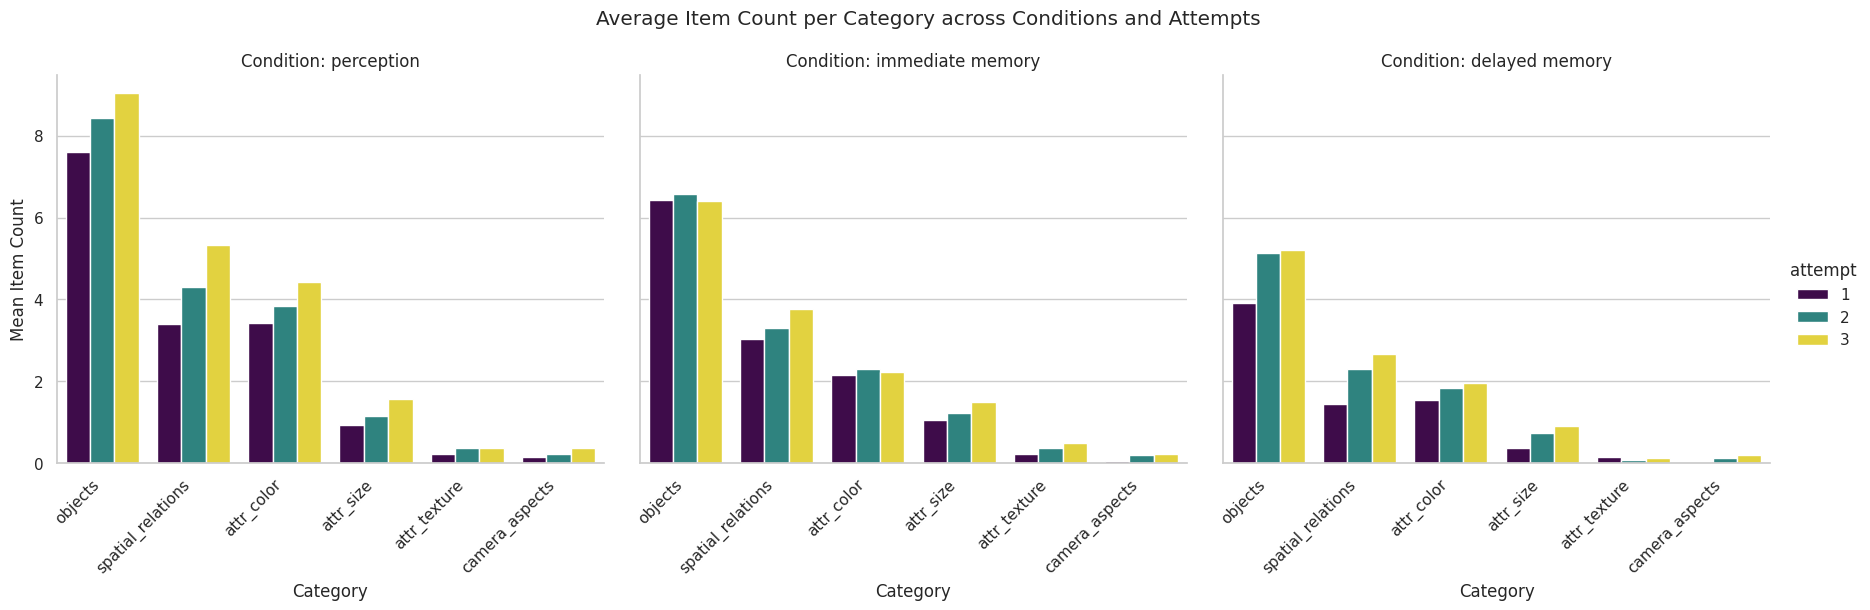

In [126]:
# Setting up the visual style
sns.set_theme(style="whitegrid")

# Creating the faceted bar plot
g = sns.catplot(
    data=agg_df, 
    x='category', 
    y='count', 
    hue='attempt', 
    col='condition', 
    kind='bar',
    palette='viridis',
    height=5, 
    aspect=1.2
)
# Diagonal Labels
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Customizing labels and titles
g.set_axis_labels("Category", "Mean Item Count")
g.set_titles("Condition: {col_name}")
g.fig.suptitle('Average Item Count per Category across Conditions and Attempts', y=1.05)

# plt.savefig('category_analysis_plot.png', bbox_inches='tight')
plt.show()

In [20]:
import plotly.graph_objects as go
import pandas as pd

# 1. Prepare Data
condition_order = ['perception', 'immediate memory', 'delayed memory']
# Ensure it's categorical for sorting, but we'll use strings for grouping
agg_df['condition'] = pd.Categorical(agg_df['condition'], categories=condition_order, ordered=True)
agg_df = agg_df.sort_values(['category', 'condition', 'attempt'])

# Bar data: Mean of attempts (using observed=True to fix your previous warning)
bar_df = agg_df.groupby(['category', 'condition'], as_index=False, observed=True)['count'].mean()

# 2. Create Figure
fig = go.Figure()

# 3. Add the Bars (Viridis Palette)
# Viridis Hex: Dark Purple, Teal/Green, Yellow
viridis_colors = ['#440154', '#21918c', '#fde725'] 

for i, cond in enumerate(condition_order):
    cond_data = bar_df[bar_df['condition'] == cond]
    fig.add_trace(go.Bar(
        x=cond_data['category'],
        y=cond_data['count'],
        name=cond,
        marker_color=viridis_colors[i],
        opacity=0.6,
        offsetgroup=cond  # String name of the condition
    ))

# 4. Add the Dots (Attempt 1, 2, 3)
# We loop through attempts. Each dot must know which BAR (condition) it belongs to.
attempt_colors = ['#FF4136', '#2ECC40', '#0074D9'] # Red, Green, Blue

for j, att in enumerate([1, 2, 3]):
    att_data = agg_df[agg_df['attempt'] == att]
    
    fig.add_trace(go.Scatter(
        x=att_data['category'],
        y=att_data['count'],
        name=f"Attempt {att}",
        mode='markers',
        marker=dict(
            color=attempt_colors[j], 
            size=10, 
            line=dict(width=1, color='black')
        ),
        # Crucial fix: Convert the condition column to strings so Plotly accepts them
        offsetgroup=att_data['condition'].astype(str),
        alignmentgroup=att_data['condition'].astype(str)
    ))

# 5. Styling
fig.update_layout(
    barmode='group',
    title="Count by Category and Condition with Attempt Breakdown",
    xaxis_title="Category",
    yaxis_title="Mean Count",
    xaxis_tickangle=-45,
    legend_title="Legend",
    template="plotly_white"
)

fig.show()

ValueError: 
    Invalid value of type 'pandas.core.series.Series' received for the 'alignmentgroup' property of scatter
        Received value: 0           perception
3     immediate memory
6       delayed memory
9           perception
12    immediate memory
15      delayed memory
18          perception
21    immediate memory
24      delayed memory
27          perception
30    immediate memory
33      delayed memory
36          perception
39    immediate memory
42      delayed memory
45          perception
48    immediate memory
51      delayed memory
Name: condition, dtype: object

    The 'alignmentgroup' property is a string and must be specified as:
      - A string
      - A number that will be converted to a string

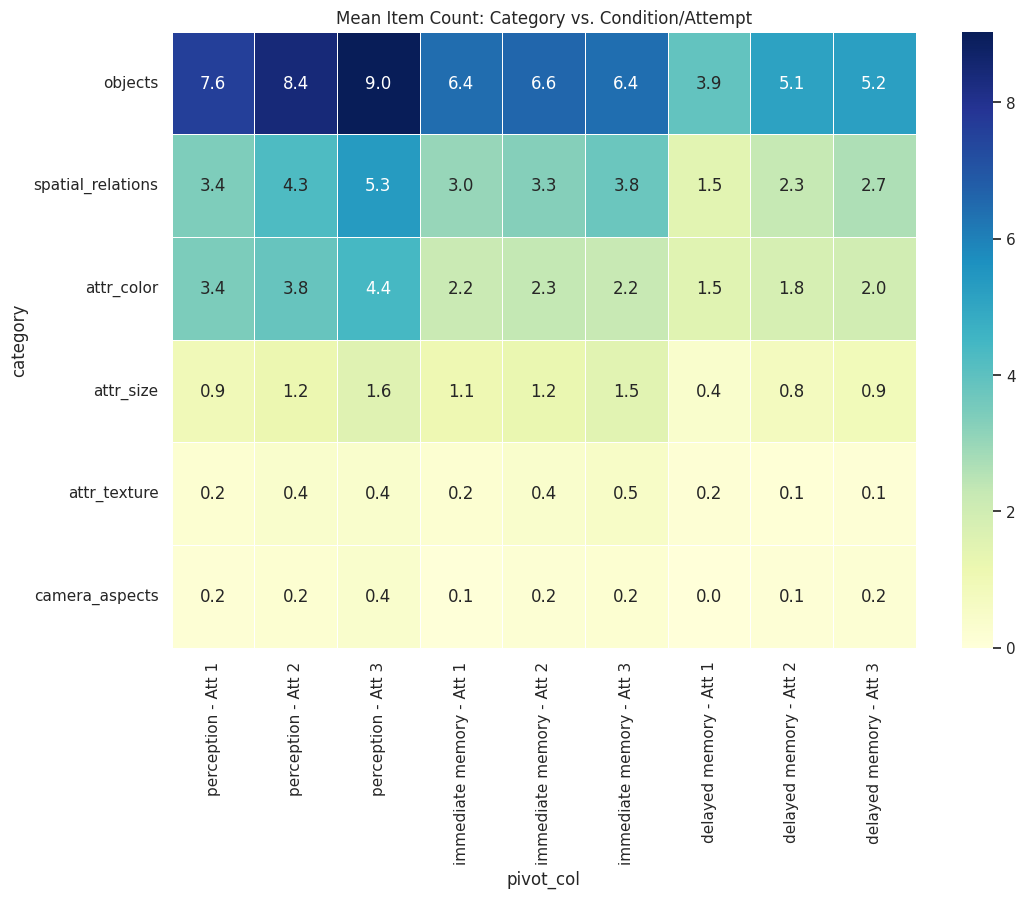

In [130]:
# Create a combined label for the heatmap columns
agg_df['pivot_col'] = agg_df['condition'].astype(str) + " - Att " + agg_df['attempt'].astype(str)

pivot_df = agg_df.pivot(index="category", columns="pivot_col", values="count")

# Reorder columns to follow your condition order
cols = []
for cond in condition_order:
    for att in [1, 2, 3]:
        cols.append(f"{cond} - Att {att}")
pivot_df = pivot_df[cols]

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt=".1f", linewidths=.5)
plt.title("Mean Item Count: Category vs. Condition/Attempt")
plt.show()

# with participant variability

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Clean the Condition names and set the order
# Ensure your strings match these exactly (check for capitalization/spaces)
condition_order = ['perception', 'immediate memory', 'delayed memory']
long['condition'] = pd.Categorical(long['condition'], categories=condition_order, ordered=True)

# 2. Correct Aggregation
# We include 'condition' in the groupby to keep the participant tied to their group.
# We average the 'count' (averaging across the multiple images 'gt' each person saw).
df_participant = long.groupby(
    ['condition', 'uid', 'category', 'attempt'], 
    as_index=False, 
    observed=True  # IMPORTANT: This prevents pandas from creating empty rows for 
                   # combinations that don't exist (like User A in Condition B)
)['count'].mean()


# 1. choose only 3rd attempt for the plot, as it is the max ability of the participant:
df_attempt_3 = long[long['attempt'] == 3].copy()

# 3. Verify the structure
df_participant.sample(9)
# You should see that any given 'uid' is only ever associated with one 'condition'.

,condition,uid,category,attempt,count
192,immediate memory,qn36ndly1767638614323,attr_texture,1,0.200000
139,immediate memory,7soec8jg1767640158456,attr_texture,2,0.200000
116,immediate memory,6wvnde9x1767643758827,attr_color,3,2.000000
245,delayed memory,8ypjsdwl1770557442675,attr_size,3,0.500000
291,delayed memory,haandeb51770671294588,spatial_relations,1,0.666667
28,perception,734m52011765314517645,attr_size,2,0.600000
314,delayed memory,reeboiaw1770666301393,attr_color,3,1.250000
286,delayed memory,g9hixqxy1770656910040,camera_aspects,2,0.000000
188,immediate memory,qn36ndly1767638614323,attr_color,3,1.000000


/tmp/ipykernel_133066/115268621.py:29: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_133066/115268621.py:29: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_133066/115268621.py:29: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


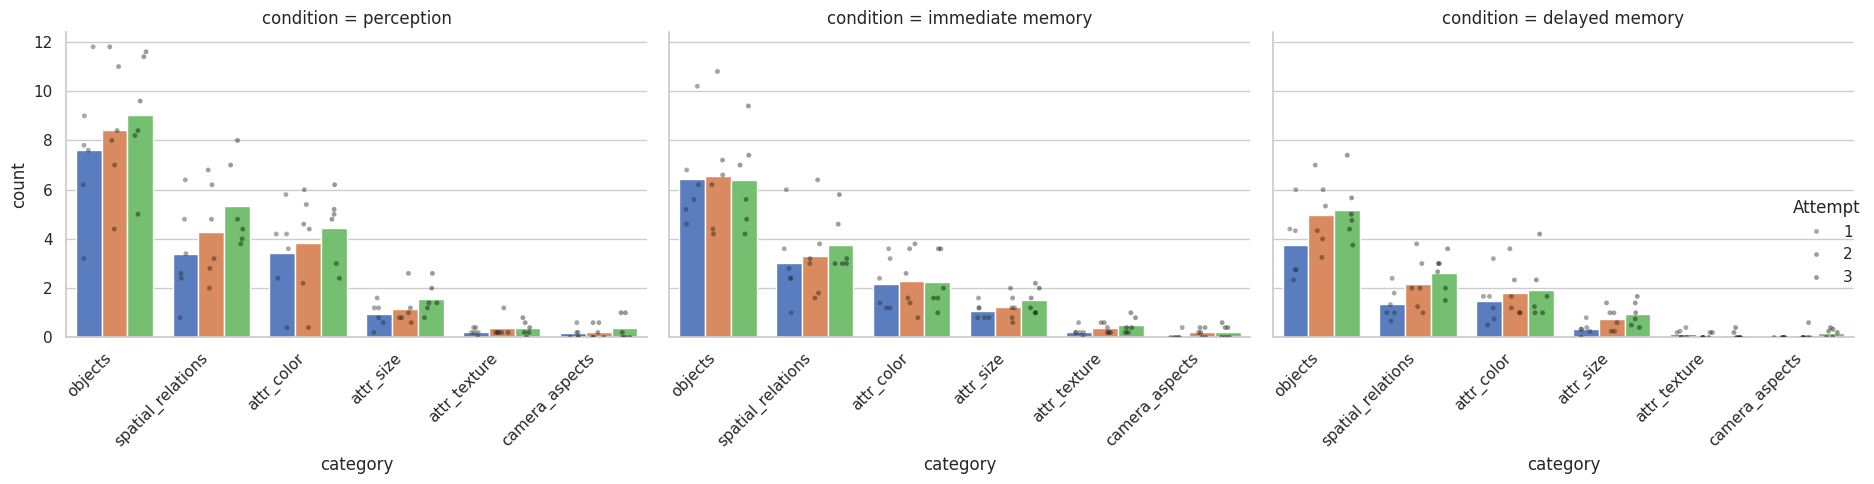

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Choose your colors
bar_palette = "muted"   # "muted", "deep", or "Dark2" are good for darker bars
dot_color = "black"     # Using a single dark color for dots often looks cleaner

sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    df_participant, 
    col="condition", 
    col_order=['perception', 'immediate memory', 'delayed memory'],
    height=5, 
    aspect=1.2
)

def draw_study_data(data, **kwargs):
    ax = plt.gca()
    
    # DARKER BARS: alpha=1.0 makes them fully opaque
    sns.barplot(
        data=data, x="category", y="count", hue="attempt",
        palette=bar_palette, alpha=1.0, errorbar=None, ax=ax
    )
    
    # CONTRASTING DOTS: Using 'black' or '0.2' (dark gray) 
    # dodge=True keeps them aligned with the specific attempt bar
    sns.stripplot(
        data=data, x="category", y="count", hue="attempt",
        color=dot_color, dodge=True, alpha=0.4, size=3.5, jitter=0.2, ax=ax
    )
    
    if ax.get_legend(): ax.get_legend().remove()

g.map_dataframe(draw_study_data)

# Diagonal Labels
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

g.add_legend(title="Attempt")
plt.tight_layout()
plt.show()

/tmp/ipykernel_5079/2303971856.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df_attempt_3.groupby(


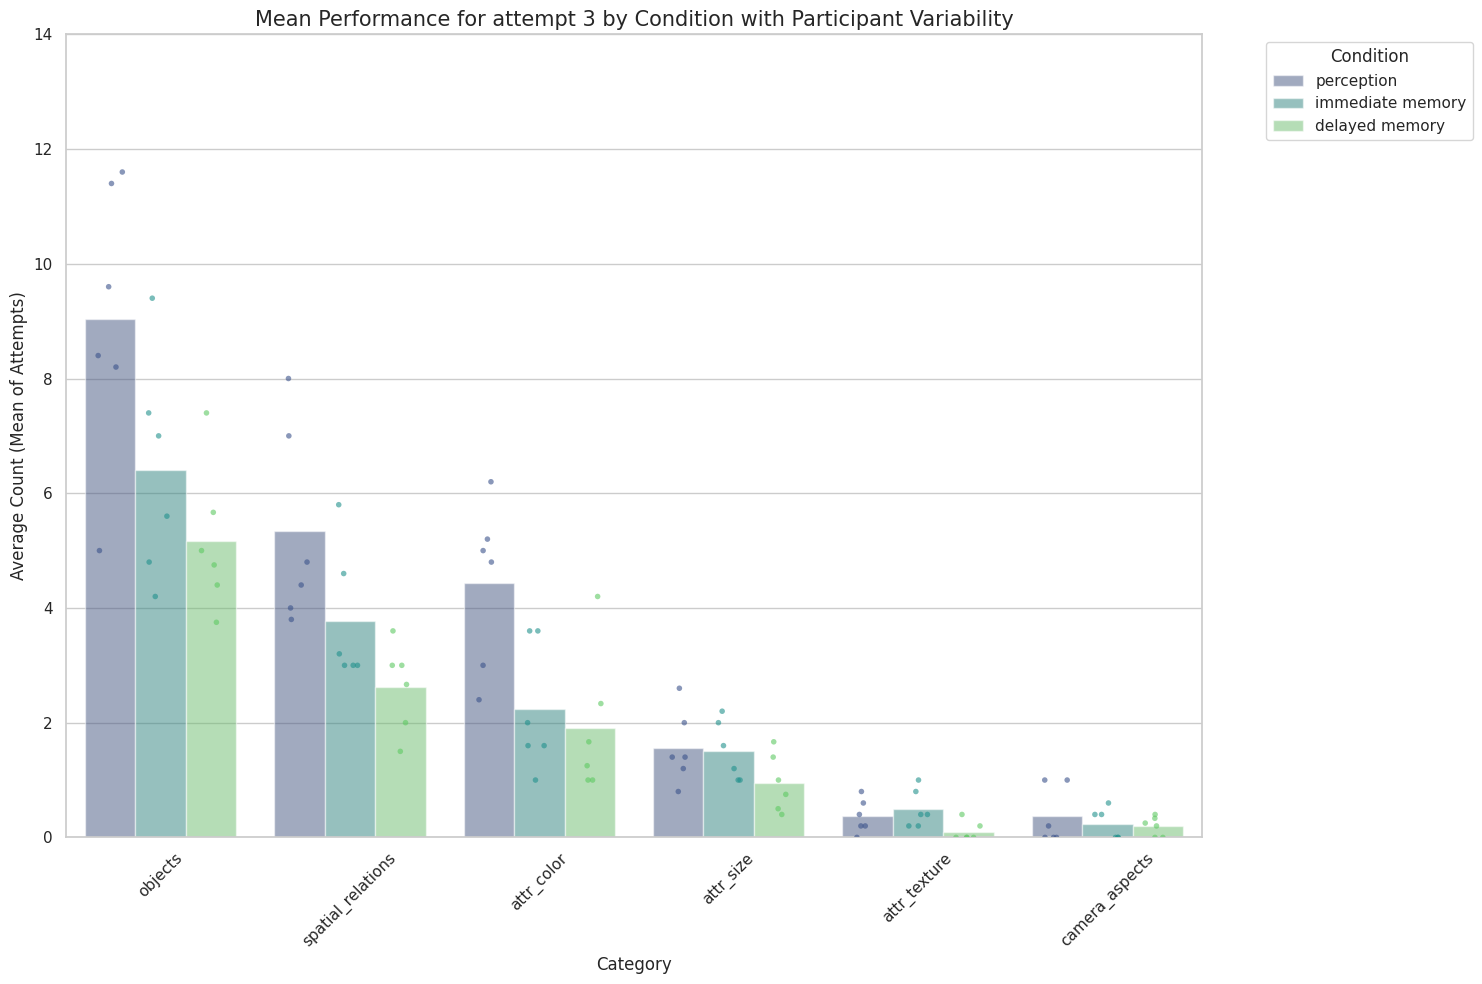

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. choose only 3rd attempt for the plot, as it is the max ability of the participant:
df_attempt_3 = long[long['attempt'] == 3].copy()

# --- 2. Aggregate per participant/category for Attempt 3 ---
# Since we filtered for one attempt, .mean() here just handles multiple 'gt' images
df_plot = df_attempt_3.groupby(
    ['condition', 'uid', 'category'], 
    as_index=False
)['count'].mean()

# 2. Set the aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

# 3. Create the Bar Plot (Remove error bars here)
ax = sns.barplot(
    data=df_plot,
    x='category',
    y='count',
    hue='condition',
    palette='viridis',
    alpha=0.5,      # Make bars slightly transparent so dots stand out
    errorbar=None   # Remove the standard error bars
)

# 4. Add the individual dots (one per uid)
sns.stripplot(
    data=df_plot,
    x='category',
    y='count',
    hue='condition',
    dodge=True,          # Shift dots to align with the specific bars
    palette='viridis',
    alpha=0.6,           # Transparency for dots
    jitter=0.2,          # Spread dots horizontally so they don't overlap
    size=4,              # Size of the dots
    legend=False         # Prevent duplicate legend entries
)

# 5. Customization
plt.title('Mean Performance for attempt 3 by Condition with Participant Variability', fontsize=15)
plt.ylabel('Average Count (Mean of Attempts)')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.ylim(0, 14)
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# adding gpt to measures

In [24]:
# first let's test which gpt-5 descs to choose (remember they differ in their verbosity:)
#make a bar comparison of counts for each type of description (they differ in column "verbosity" as low, mediu, and high)
# Assuming selected_columns contains your count categories (objects, attr_color, etc.)
gpt_id_cols = ["uid", "gt", "verbosity"] 

gpt_long = df_gpt.melt(
    id_vars=gpt_id_cols,
    value_vars=selected_columns,
    var_name="category",
    value_name="items"
)

# Apply your safe_len function to get the counts
gpt_long["count"] = gpt_long["items"].apply(safe_len)

In [33]:
gpt_long

,uid,gt,verbosity,category,items,count
0,gpt-5,bedroom_l.jpg,low,objects,"[bed, post, duvet, pillow, print, headboard, w...",27
1,gpt-5,bedroom_l.jpg,medium,objects,"[bedroom, window, bed, posts, duvet, pillows, ...",24
2,gpt-5,bedroom_l.jpg,high,objects,"[bed, duvet, sheets, pillows, prints, headboar...",25
3,gpt-5,conference_room_h.jpg,low,objects,"[conference room, training room, table, chair,...",15
4,gpt-5,conference_room_h.jpg,medium,objects,"[training room, table, chair, floor, sheet of ...",17
...,...,...,...,...,...,...
85,gpt-5,living_room_h.jpg,medium,camera_aspects,"[eye level, wide angle]",2
86,gpt-5,living_room_h.jpg,high,camera_aspects,"[eye level, wide angle, sharp focus]",3
87,gpt-5,tower_l.jpg,low,camera_aspects,[low-angle],1
88,gpt-5,tower_l.jpg,medium,camera_aspects,"[low angle upward view, square format]",2


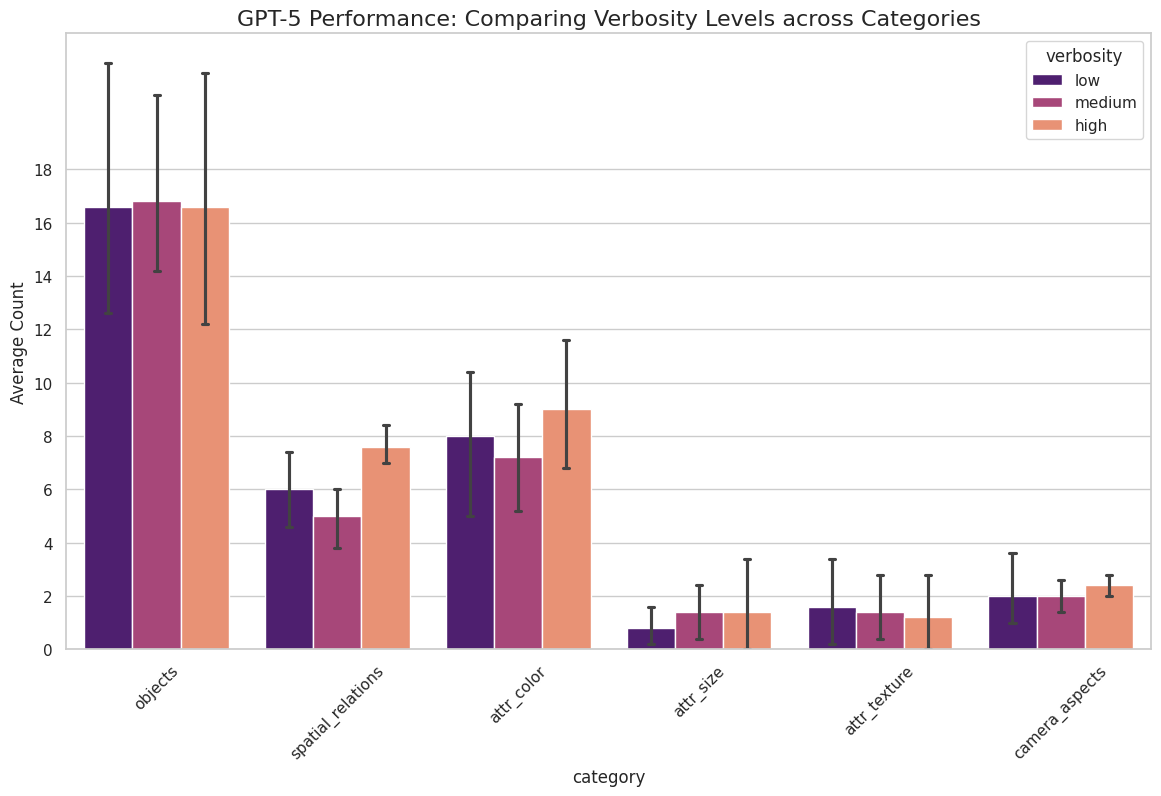

In [10]:
plt.figure(figsize=(14, 8))

sns.barplot(
    data=gpt_long,
    x='category',
    y='count',
    hue='verbosity',
    hue_order=['low', 'medium', 'high'],
    palette='magma',
    capsize=.1
)

plt.title('GPT-5 Performance: Comparing Verbosity Levels across Categories', fontsize=16)
plt.ylabel('Average Count')
plt.xticks(rotation=45)
plt.yticks(range(0, 20, 2))
plt.show()

In [25]:
# --- 1. Prepare Human Data: One dot per participant ---
# Average across 'gt' images so each (uid, condition, category) has exactly one value
df_human_dots = df_attempt_3.groupby(
    ['uid', 'condition', 'category'], 
    as_index=False
)['count'].mean()

# --- 2. Prepare GPT Data: The Ceiling ---
# Filter for your desired verbosity and average across all images for a category mean
chosen_verbosity = 'medium' 
gpt_ceiling = gpt_long[gpt_long['verbosity'] == chosen_verbosity].groupby(
    'category'
)['count'].mean()

/tmp/ipykernel_5079/2184887283.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_human_dots = df_attempt_3.groupby(


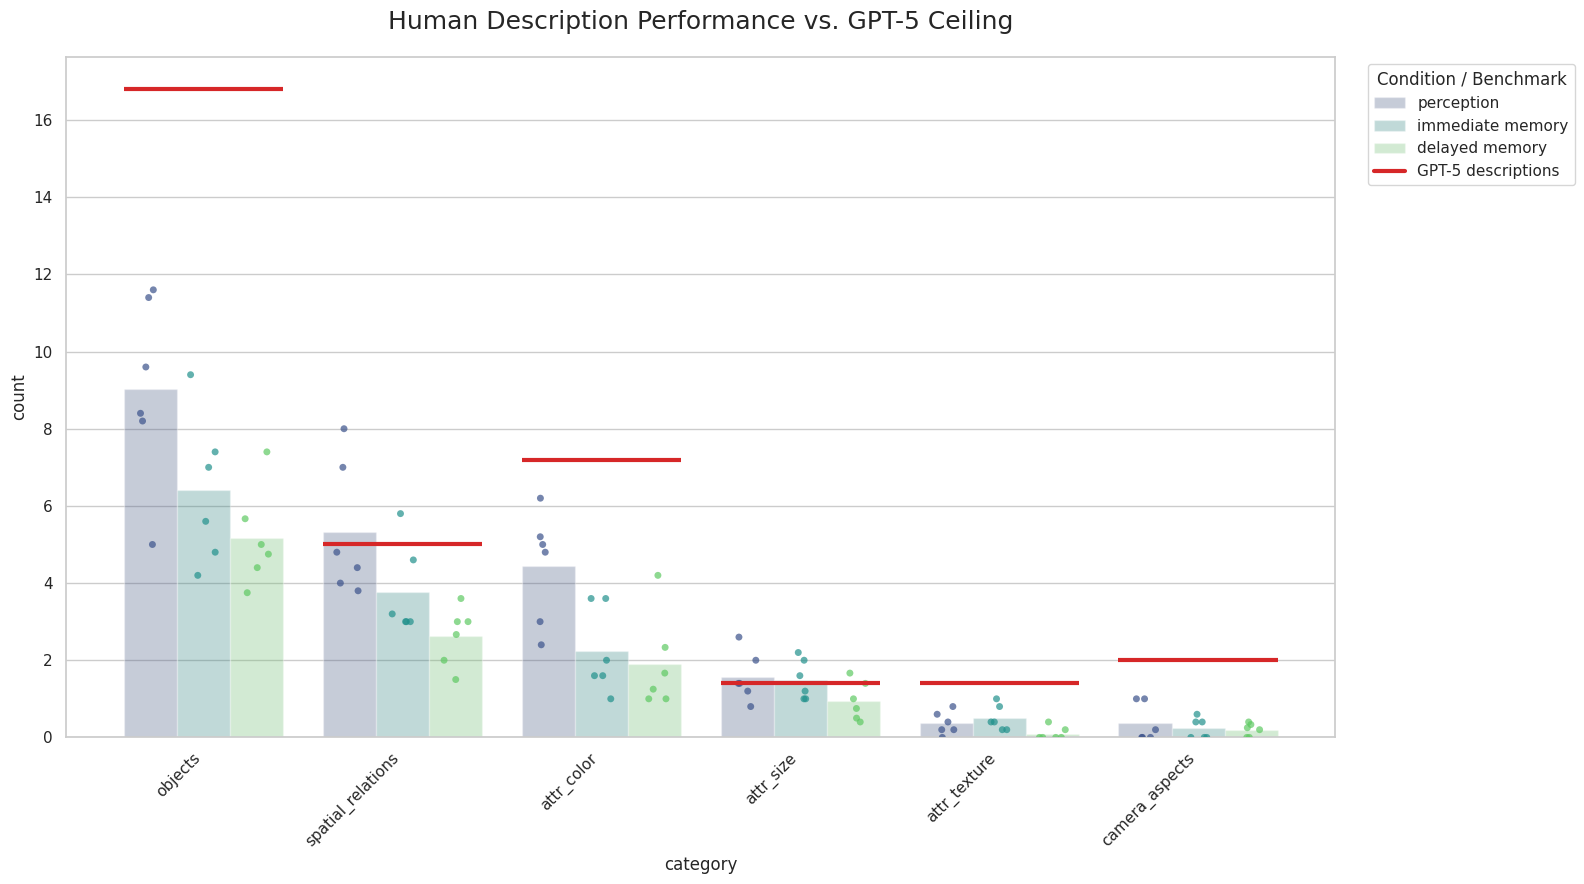

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the order and style
condition_order = ['perception', 'immediate memory', 'delayed memory']
df_human_dots['condition'] = pd.Categorical(df_human_dots['condition'], categories=condition_order, ordered=True)
category_list = selected_columns # Ensure this matches your x-axis order

plt.figure(figsize=(16, 9))
ax = sns.barplot(data=df_human_dots, x='category', y='count', hue='condition', palette='viridis', alpha=0.3, errorbar=None)
sns.stripplot(data=df_human_dots, x='category', y='count', hue='condition', dodge=True, palette='viridis', alpha=0.7, jitter=0.2, size=5, legend=False)

# --- NEW: GPT Horizontal Bars per Category ---
# Define how wide you want each ceiling line to be (0.8 is roughly the width of the 3 bars)
line_width = 0.8 

for i, category in enumerate(category_list):
    y_val = gpt_ceiling[category]
    # xmin and xmax are relative to the category index (i)
    plt.hlines(y=y_val, xmin=i - line_width/2, xmax=i + line_width/2, 
               color='#d62728', linestyle='-', linewidth=3, zorder=5)
    
    # Optional: Add a single legend entry for the red line
    if i == 0:
        plt.plot([], [], color='#d62728', label=f'GPT-5 descriptions', linewidth=3)

# Final formatting
plt.title('Human Description Performance vs. GPT-5 Ceiling', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Condition / Benchmark', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# comparison with gpt and with wilma

In [29]:
df_wilma

,category,condition,count,type
0,objects,perception,9.4,drawing
1,objects,immediate memory,7.8,drawing
2,objects,delayed memory,7.0,drawing


In [33]:
# humans descriptions (3rd attempt) vs wilma (drawings) with gpt as a ceiling
# 1. Filter human description data for 'objects'
human_objs = df_human_dots[df_human_dots['category'] == 'objects'].copy()
human_objs['Type'] = 'Description'

# 2.
#add another column called type whos value is drawing:
df_wilma['Type'] = 'Drawing'

# 3. Combine them for plotting
comparison_df = pd.concat([human_objs, df_wilma], ignore_index=True)

# Ensure condition order
condition_order = ['perception', 'immediate memory', 'delayed memory']
comparison_df['condition'] = pd.Categorical(comparison_df['condition'], categories=condition_order, ordered=True)

In [34]:
comparison_df

,uid,condition,category,count,Type,type
0,17t99kvz1765301165519,perception,objects,9.600000,Description,NaN
1,17t99kvz1765301165519,immediate memory,objects,NaN,Description,NaN
2,17t99kvz1765301165519,delayed memory,objects,NaN,Description,NaN
3,26b1mnt51770668623350,perception,objects,NaN,Description,NaN
4,26b1mnt51770668623350,immediate memory,objects,NaN,Description,NaN
5,26b1mnt51770668623350,delayed memory,objects,7.400000,Description,NaN
6,6wvnde9x1767643758827,perception,objects,NaN,Description,NaN
7,6wvnde9x1767643758827,immediate memory,objects,5.600000,Description,NaN
8,6wvnde9x1767643758827,delayed memory,objects,NaN,Description,NaN
9,734m52011765314517645,perception,objects,5.000000,Description,NaN


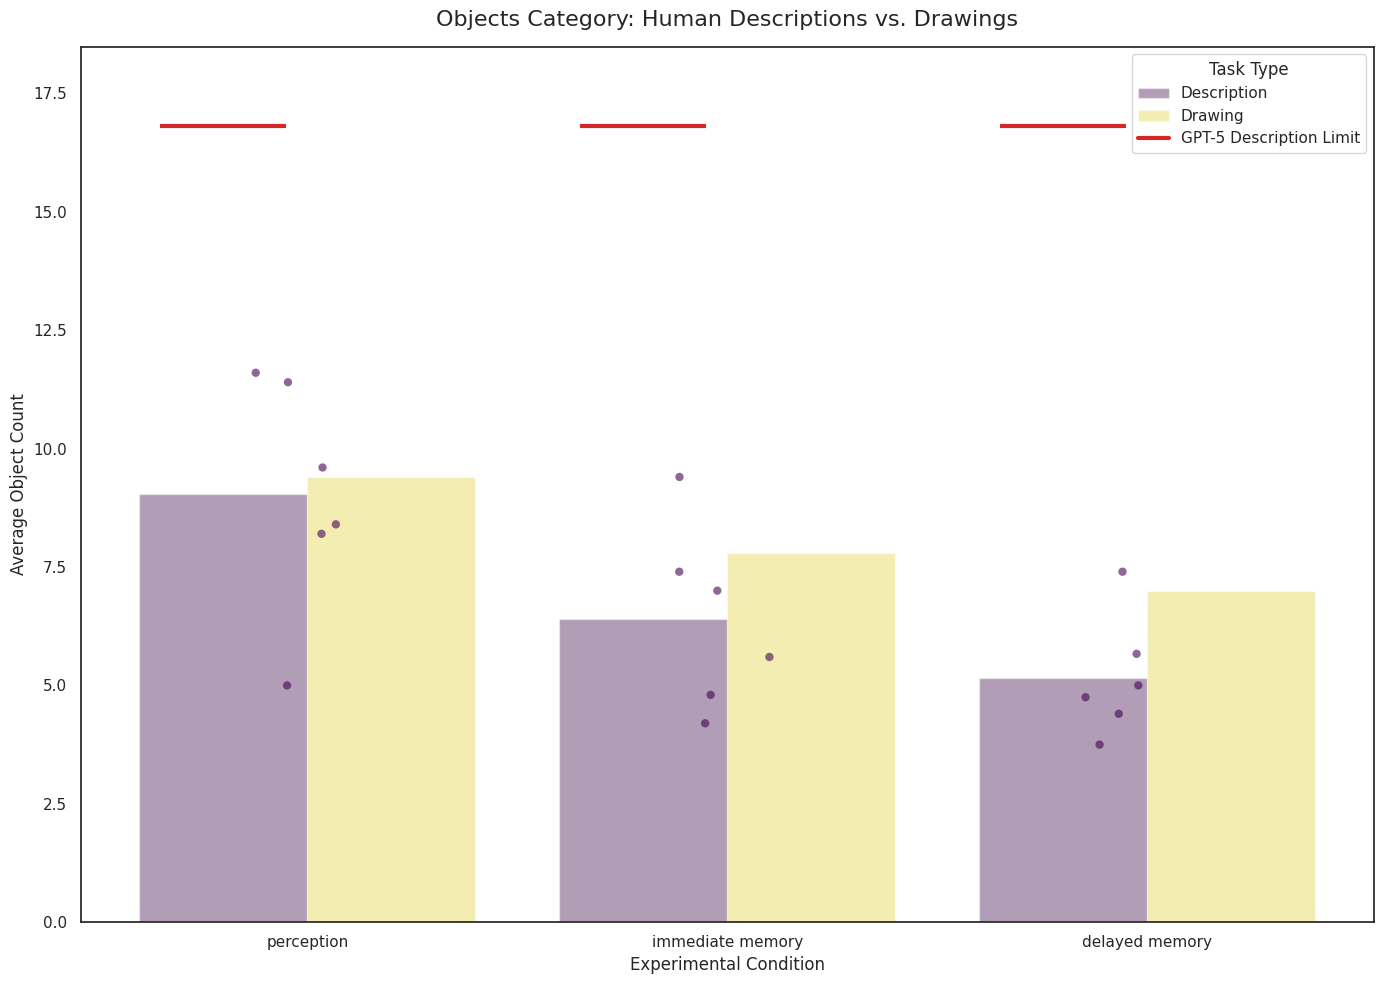

In [36]:
plt.figure(figsize=(14, 10))
sns.set_theme(style="white")

# --- A. Draw the Comparison Bars ---
ax = sns.barplot(
    data=comparison_df,
    x='condition',
    y='count',
    hue='Type',
    palette=['#440154', '#fde725'], # Dark purple for Descriptions, Yellow for Drawings
    alpha=0.4,
    errorbar=None
)

# --- B. Add Participant Dots (Descriptions only) ---
# We use the same 'hue' and 'dodge' to align dots with the Description bars
sns.stripplot(
    data=human_objs,
    x='condition',
    y='count',
    hue='Type',
    dodge=True,
    palette=['#440154'],
    alpha=0.6,
    jitter=0.15,
    size=6,
    legend=False
)

# --- C. Add the GPT Ceiling (Description Upper Limit) ---
# For 'objects', GPT was ~16.8 in your previous data
gpt_obj_limit = gpt_ceiling['objects'] 
line_width = 0.3  # Width of the individual ceiling caps

# We iterate through the conditions and place a line over the first bar (Description)
for i in range(len(condition_order)):
    # In a 2-hue bar plot, the center of the first bar is at i - 0.2
    x_pos = i - 0.2 
    plt.hlines(
        y=gpt_obj_limit, 
        xmin=x_pos - line_width/2, 
        xmax=x_pos + line_width/2, 
        color='#d62728', linewidth=3, zorder=5
    )

# Legend entry for the ceiling
plt.plot([], [], color='#d62728', label='GPT-5 Description Limit', linewidth=3)

# --- D. Final Polish ---
plt.title('Objects Category: Human Descriptions vs. Drawings', fontsize=16, pad=15)
plt.ylabel('Average Object Count', fontsize=12)
plt.xlabel('Experimental Condition', fontsize=12)
plt.ylim(0, max(gpt_obj_limit, comparison_df['count'].max()) * 1.1)
plt.legend(title='Task Type', loc='upper right')

plt.tight_layout()
plt.show()